In [ ]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import xml.etree.ElementTree as ET

from google.colab import drive

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    ReLU,
    Add,
    GlobalAveragePooling2D,
    DepthwiseConv2D,
    Multiply,
    Reshape,
    Concatenate
)

from tensorflow.keras.optimizers import Adam

In [ ]:
# ==========================================
# MOUNT GOOGLE DRIVE
# ==========================================

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================
# DATASET PATHS
# ==========================================

train_images = "/content/drive/MyDrive/NEU-DET/train/images"

train_labels = "/content/drive/MyDrive/NEU-DET/train/annotations"

val_images = "/content/drive/MyDrive/NEU-DET/validation/images"

val_labels = "/content/drive/MyDrive/NEU-DET/validation/annotations"

output_path = "/content/dataset"

In [ ]:
# ==========================================
# CLASSES
# ==========================================

classes = [

    "crazing",

    "inclusion",

    "patches",

    "pitted_surface",

    "rolled_in_scale",

    "scratches"
]

In [ ]:
# ==========================================
# CREATE OUTPUT FOLDERS
# ==========================================

for split in ["train", "validation"]:

    for cls in classes:

        os.makedirs(
            os.path.join(output_path, split, cls),
            exist_ok=True
        )

In [ ]:
# ==========================================
# DATASET CONVERSION FUNCTION
# ==========================================

def convert_dataset(image_dir, label_dir, split):

    for xml_file in os.listdir(label_dir):

        xml_path = os.path.join(label_dir, xml_file)

        tree = ET.parse(xml_path)

        root = tree.getroot()

        obj = root.find("object")

        class_name = obj.find("name").text

        image_file = xml_file.replace(".xml", ".jpg")

        image_path = os.path.join(image_dir, image_file)

        dest_path = os.path.join(
            output_path,
            split,
            class_name,
            image_file
        )

        if os.path.exists(image_path):

            shutil.copy(image_path, dest_path)

In [ ]:
# ==========================================
# CONVERT DATASET
# ==========================================

convert_dataset(
    train_images,
    train_labels,
    "train"
)

convert_dataset(
    val_images,
    val_labels,
    "validation"
)

In [ ]:
# ==========================================
# DATASET PATHS
# ==========================================

train_dir = "/content/drive/MyDrive/NEU-DET/train/images"
val_dir = "/content/drive/MyDrive/NEU-DET/validation/images"

In [ ]:
# ==========================================
# IMAGE PREPROCESSING
# ==========================================

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True
)

val_datagen = ImageDataGenerator(

    rescale=1./255
)

In [ ]:
# ==========================================
# LOAD DATASET
# ==========================================

train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=(128,128),

    color_mode="rgb",

    batch_size=32,

    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(

    val_dir,

    target_size=(128,128),

    color_mode="rgb",

    batch_size=32,

    class_mode='categorical'
)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.


In [ ]:
# ==========================================
# PRINT CLASSES
# ==========================================

print(train_generator.class_indices)

{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


In [ ]:
# ==========================================
# SQUEEZE EXCITATION BLOCK
# ==========================================

def se_block(input_tensor, ratio=8):

    filters = input_tensor.shape[-1]

    se = GlobalAveragePooling2D()(input_tensor)

    se = Dense(filters // ratio, activation='relu')(se)

    se = Dense(filters, activation='sigmoid')(se)

    se = Reshape((1,1,filters))(se)

    x = Multiply()([input_tensor, se])

    return x

In [ ]:
# ==========================================
# MBConv BLOCK
# ==========================================

def mbconv_block(x, filters):

    shortcut = x

    # Expand
    x = Conv2D(filters * 2, (1,1), padding='same')(x)

    x = BatchNormalization()(x)

    x = ReLU()(x)

    # Depthwise convolution
    x = DepthwiseConv2D((3,3), padding='same')(x)

    x = BatchNormalization()(x)

    x = ReLU()(x)

    # SE Attention
    x = se_block(x)

    # Projection
    x = Conv2D(filters, (1,1), padding='same')(x)

    x = BatchNormalization()(x)

    # Residual connection
    if shortcut.shape[-1] == filters:

        x = Add()([x, shortcut])

    return x

In [ ]:
# ==========================================
# HYBRID CNN MODEL
# ==========================================

inputs = Input(shape=(128,128,3))

# ==========================================
# BLOCK 1
# ==========================================

x = Conv2D(32,(3,3),padding='same')(inputs)

x = BatchNormalization()(x)

x = ReLU()(x)

x = Conv2D(32,(3,3),padding='same')(x)

x = BatchNormalization()(x)

x = ReLU()(x)

x = MaxPooling2D((2,2))(x)

x = Dropout(0.25)(x)

# ==========================================
# BLOCK 2
# ==========================================

shortcut1 = x

x = Conv2D(64,(3,3),padding='same')(x)

x = BatchNormalization()(x)

x = ReLU()(x)

x = Conv2D(64,(3,3),padding='same')(x)

x = BatchNormalization()(x)

shortcut1 = Conv2D(64,(1,1),padding='same')(shortcut1)

x = Add()([x, shortcut1])

x = ReLU()(x)

x = MaxPooling2D((2,2))(x)

x = Dropout(0.25)(x)

# ==========================================
# BLOCK 3
# ==========================================

shortcut2 = x

x = Conv2D(128,(3,3),padding='same')(x)

x = BatchNormalization()(x)

x = ReLU()(x)

x = Conv2D(128,(3,3),padding='same')(x)

x = BatchNormalization()(x)

shortcut2 = Conv2D(128,(1,1),padding='same')(shortcut2)

x = Add()([x, shortcut2])

x = ReLU()(x)

x = MaxPooling2D((2,2))(x)

x = Dropout(0.30)(x)

# ==========================================
# BLOCK 4
# ==========================================

shortcut3 = x

x = Conv2D(256,(3,3),padding='same')(x)

x = BatchNormalization()(x)

x = ReLU()(x)

x = Conv2D(256,(3,3),padding='same')(x)

x = BatchNormalization()(x)

shortcut3 = Conv2D(256,(1,1),padding='same')(shortcut3)

x = Add()([x, shortcut3])

x = ReLU()(x)

x = MaxPooling2D((2,2))(x)

x = Dropout(0.40)(x)

# ==========================================
# MBConv BLOCKS
# ==========================================

x = mbconv_block(x, 256)

x = mbconv_block(x, 256)

# ==========================================
# GLOBAL AVERAGE POOLING
# ==========================================

x = GlobalAveragePooling2D()(x)

# ==========================================
# FULLY CONNECTED LAYERS
# ==========================================

x = Dense(256, activation='relu')(x)

x = Dropout(0.50)(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.30)(x)

# ==========================================
# OUTPUT LAYER
# ==========================================

outputs = Dense(6, activation='softmax')(x)

# ==========================================
# FINAL MODEL
# ==========================================

model = Model(inputs, outputs)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_62[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_50 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 128, 128,  │      9,248 │ re_lu_50[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_63[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_51 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 64, 64,    │          0 │ re_lu_51[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 64, 64,    │          0 │ max_pooling2d_16… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 64, 64,    │     18,496 │ dropout_25[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_64[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_52 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 64, 64,    │     36,928 │ re_lu_52[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_65[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 64, 64,    │      2,112 │ dropout_25[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d_66[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_53 (ReLU)     │ (None, 64, 64,    │          0 │ add_21[0][0]    

 Total params: 1,997,542 (7.62 MB)

 Trainable params: 1,990,502 (7.59 MB)

 Non-trainable params: 7,040 (27.50 KB)

In [ ]:
# ==========================================
# COMPILE MODEL
# ==========================================

model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [ ]:
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=20,

)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 305ms/step - accuracy: 0.6646 - loss: 0.9469 - val_accuracy: 0.1667 - val_loss: 2.1610
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 302ms/step - accuracy: 0.7278 - loss: 0.7750 - val_accuracy: 0.1667 - val_loss: 2.4487
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 302ms/step - accuracy: 0.7778 - loss: 0.6539 - val_accuracy: 0.1667 - val_loss: 2.8046
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 307ms/step - accuracy: 0.7924 - loss: 0.5824 - val_accuracy: 0.1667 - val_loss: 3.0892
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 298ms/step - accuracy: 0.8382 - loss: 0.4870 - val_accuracy: 0.1667 - val_loss: 3.1785
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 13s 298ms/step - accuracy: 0.8569 - loss: 0.4314 - val_accuracy: 0.1694 - val_loss: 3.2279
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 302ms/step - accuracy: 0.8431 - loss: 0.4512 - val_accuracy: 0.1667 - val_loss: 3.8384
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 299ms/step - accuracy: 0.8667 - loss: 0.4153 - val_accu

In [ ]:
# ==========================================
# SAVE MODEL
# ==========================================

model.save("hybrid_defect_detection_model.h5")

In [ ]:
# ==========================================
# EVALUATE MODEL
# ==========================================

loss, accuracy = model.evaluate(validation_generator)

print("Validation Accuracy :", accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step - accuracy: 0.6139 - loss: 1.8096
Validation Accuracy : 0.6138888597488403


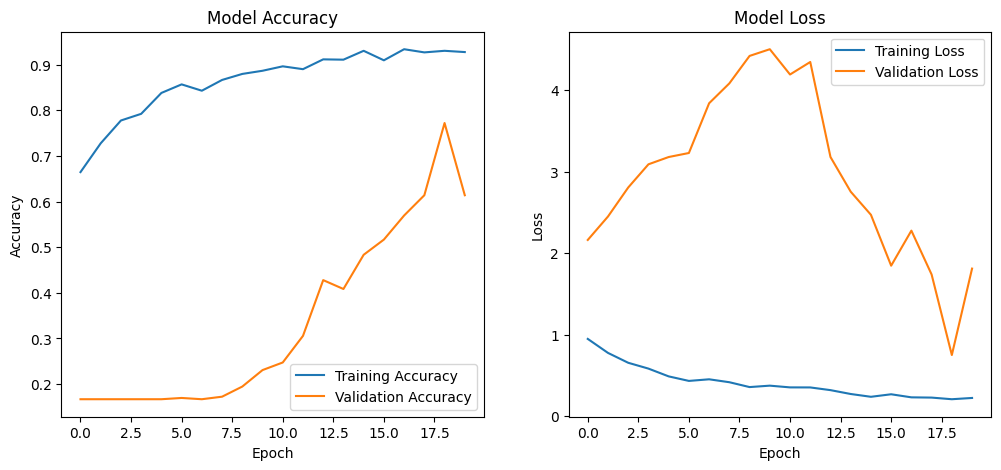

In [ ]:
# Accuracy Graph
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Training Accuracy','Validation Accuracy'])

# Loss Graph
plt.subplot(1,2,2)

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Training Loss','Validation Loss'])

plt.show()

In [ ]:
from google.colab import files
from tensorflow.keras.models import load_model

# ================= UPLOAD MODEL =================
uploaded = files.upload()

# ================= GET MODEL FILE NAME =================
model_path = list(uploaded.keys())[0]

# ================= LOAD MODEL =================
model = load_model(model_path)

# ================= CONFIRM =================
print("Model loaded successfully!")
print("Model name:", model_path)

Saving hybrid_defect_detection_model.h5 to hybrid_defect_detection_model.h5


Model loaded successfully!
Model name: hybrid_defect_detection_model.h5


Saving patches.png to patches.png


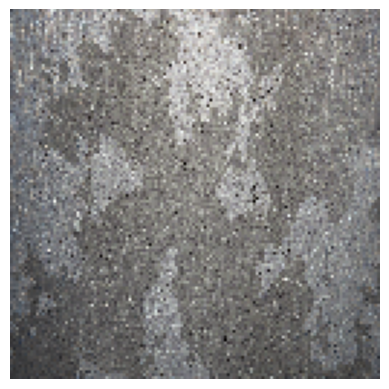

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Defect : crazing
Confidence : 100.0


In [ ]:
# ==========================================
# IMPORTS (IMPORTANT)
# ==========================================
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# UPLOAD IMAGE
# ==========================================




uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# ==========================================
# LOAD IMAGE
# ==========================================
img = image.load_img(
    img_path,
    target_size=(128, 128)
)

# ==========================================
# SHOW IMAGE
# ==========================================
plt.imshow(img)
plt.axis('off')
plt.show()
classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]
# ==========================================
# PREPROCESS IMAGE
# ==========================================
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ==========================================
# PREDICT
# ==========================================
prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)
predicted_class = classes[predicted_index]
confidence = np.max(prediction) * 100

# ==========================================
# OUTPUT
# ==========================================
print("Predicted Defect :", predicted_class)
print("Confidence :", confidence)